Q1 Define Data Quality in the context of ETL pipelines. Why is it more than just data cleaning?

A) Data Quality in the context of ETL pipelines refers to the accuracy, completeness, consistency, reliability, and relevance of data as it moves from source systems through extraction, transformation, and loading into a target system (like a warehouse or lake).

It ensures that the data is not only free from obvious errors but also fit for its intended purpose — whether that’s analytics, reporting, compliance, or decision‑making.

**Accuracy**

Values must reflect reality (e.g., sales figures match actual transactions).

Cleaning alone doesn’t guarantee accuracy if the source data itself is wrong.

**Completeness**

All required fields and records must be present.

Missing data flags, imputation, and validation rules are part of quality, not just cleaning.

**Consistency**

Data must be uniform across systems (e.g., “USA” vs “United States”).

Quality enforces standards across multiple sources, not just within one dataset.

**Timeliness**

Data must be up‑to‑date and available when needed.

Cleaning doesn’t address whether data arrives late or is outdated.

**Validity & Compliance**

Data must conform to business rules, formats, and regulatory requirements.

Example: financial records must meet audit standards. Cleaning alone won’t enforce compliance.

**Reliability & Trustworthiness**

Stakeholders must trust the data for decision‑making.

Quality frameworks include monitoring, profiling, and governance — beyond simple error correction.


- Data Cleaning = fixing errors, duplicates, missing values.

- Data Quality = a holistic framework ensuring data is accurate, complete, consistent, timely, valid, and reliable across the entire ETL pipeline.



---

Q2  Explain why poor data quality leads to misleading dashboards and incorrect decisions.

A)
**1 Inaccurate Metrics**

If sales figures are duplicated or mis‑entered, dashboards may show inflated revenue.

Decision makers might believe performance is stronger than reality.

**2 Incomplete Insights**

Missing values (e.g., customer income, regional sales) distort averages and totals.

Dashboards may hide underperforming segments simply because data wasn’t captured.

**3 Inconsistent Reporting**

Different formats (“USA” vs “United States”) cause fragmented views.

Dashboards may split one country into multiple entries, misleading trend analysis.

**4 Outdated or Untimely Data**

If ETL pipelines load stale data, dashboards reflect yesterday’s reality.

Leaders may act on outdated trends, missing urgent issues.

**5 Violation of Business Rules**

Invalid entries (e.g., negative ages, impossible dates) skew KPIs.

Dashboards may highlight false anomalies or hide genuine risks.

- Strategic Errors: Executives may allocate resources to “high‑performing” regions that are actually data artifacts.

- Operational Mistakes: Marketing campaigns may target the wrong customer segments because demographic data is incomplete.

- Financial Risks: Forecasts based on poor quality data can misguide investments, pricing, or credit risk assessments.

- Loss of Trust: Once stakeholders realize dashboards are unreliable, confidence in analytics collapses — even when later data is correct.



---

Q3 What is duplicate data? Explain three causes in ETL pipelines.

A) 🔹 What is Duplicate Data?

In ETL pipelines, duplicate data refers to records that appear more than once in a dataset, either fully identical or partially overlapping.

Example: Two rows for the same customer with the same ID and details.

Duplicates inflate counts, distort metrics, and can mislead analytics if not handled.

🔹 Three Common Causes of Duplicate Data in ETL

1. Multiple Source Systems

When data is extracted from different systems (CRM, ERP, web apps), the same entity may be recorded in each.

Example: A customer appears in both the sales database and the marketing database, leading to duplicate entries after integration.

2. Data Entry Errors

Manual input or inconsistent practices can create duplicates.

Example: A customer registers twice with slightly different spellings (“Rahul Mehta” vs “Rahul M.”), which ETL may not detect as the same person.

3. Improper Joins or Merge Logic

During transformation, incorrect SQL joins or union operations can replicate rows.

Example: Using UNION ALL instead of UNION when combining tables, or joining on a non‑unique key, produces duplicate records.

🔹 Why It Matters

Dashboards: Inflated totals (e.g., double counting sales).

Analytics: Skewed averages and trends.

Business Decisions: Misallocation of resources based on faulty insights.


---

Q4 Differentiate between exact, partial, and fuzzy duplicates.

A) 1. Exact Duplicates

Definition: Records that are completely identical across all fields.

    Customer_ID: 101, Name: Rahul Mehta, Income: 45000
    Customer_ID: 101, Name: Rahul Mehta, Income: 45000

Cause: Often introduced by repeated extraction from the same source or improper use of UNION ALL.

Impact: Inflates counts and metrics directly.

2. Partial Duplicates

Definition: Records that share some fields but differ in others.

    Customer_ID: 102, Name: Anjali Rao, Income: NULL
    Customer_ID: 102, Name: Anjali Rao, Income: 50000

Cause: Data entry errors, updates not propagated across systems, or inconsistent ETL merges.

Impact: Creates confusion about which record is correct, leading to unreliable analytics.

3. Fuzzy Duplicates

Definition: Records that represent the same entity but are not identical due to spelling variations, formatting differences, or typos.

    Customer_ID: 103, Name: Suresh Iyer, Income: 52000
    Customer_ID: 103, Name: Suresh Iyerr, Income: 52000

Cause: Human input errors, inconsistent standards (e.g., “USA” vs “United States”), or OCR/import mistakes.

Impact: Harder to detect automatically; requires fuzzy matching or similarity algorithms to resolve.



---

Q5 Why should data validation be performed during transformation rather than after loading?

A) 🔹 Why Data Validation Belongs in the Transformation Stage

**1 Catch Errors Early**

- If validation is done after loading, incorrect or corrupted data has already entered the warehouse.

- This pollutes the target system and may require costly rollbacks.

- Validating during transformation ensures only clean, reliable data proceeds to loading.

**2 Maintain Data Quality Standards**

- Transformation is where data is standardized, enriched, and integrated.

- Validation checks (e.g., correct formats, ranges, uniqueness) ensure that these transformations produce trustworthy outputs.

- Without validation, transformations may propagate errors (e.g., invalid dates converted into wrong formats).

**3 Prevent Downstream Impact**

- Dashboards, reports, and analytics depend on the warehouse.

- If bad data is loaded, every downstream process is affected.

- Validating during transformation acts as a quality gate before data reaches critical systems.

**4 Efficiency in Error Handling**

- It’s easier to isolate and fix issues in the staging/transformation layer than in the warehouse.

- Validation rules can log, quarantine, or reject bad records before they contaminate the final dataset.

**5 Compliance & Auditability**

- Many industries require proof that data meets standards before being stored.

- Validation during transformation provides a clear audit trail of checks applied, ensuring regulatory compliance.



---

Q6 Explain how business rules help in validating data accuracy. Give an example

A) Business rules are essentially formalized guidelines or constraints that define how data should behave according to the organization’s logic, policies, or domain knowledge. In ETL pipelines, they act as validation checkpoints to ensure data accuracy goes beyond just being “clean” — it must also be correct in context.

🔹 How Business Rules Validate Accuracy

**Domain-Specific Checks**

- They enforce rules that reflect real-world expectations.

- Example: A customer’s age must be between 18 and 100 for a credit product.

**Consistency Across Systems**

- Business rules ensure values align with organizational standards.

- Example: Product codes must follow a specific format (e.g., PRD-XXXX).

**Logical Integrity**

- They prevent contradictory or impossible data.

- Example: If Order_Status = "Delivered", then Delivery_Date cannot be NULL.

🔹 Example

- Imagine a retail ETL pipeline loading customer purchase data:

- Business Rule: Monthly_Sales cannot be negative.

- Validation: During transformation, if a record shows Monthly_Sales = -5000, the rule flags it as invalid.

- Outcome: The error is caught before loading, preventing dashboards from showing nonsensical negative sales figures.



---

Q7 Write an SQL query on Sales_Transactions to list all duplicate keys and their counts using the
business key (Customer_ID + Product_ID + Txn_Date + Txn_Amount )

A) **Explanation**

- Business Key: Defined as the combination of Customer_ID + Product_ID + Txn_Date + Txn_Amount.

- GROUP BY: Groups rows based on this business key.

- COUNT() AS DuplicateCount:* Counts how many times each key appears.

- HAVING COUNT() > 1:* Filters only those groups that occur more than once (i.e., duplicates).


(SELECT
    Customer_ID,
    Product_ID,
    Txn_Date,
    Txn_Amount,
    COUNT(*) AS DuplicateCount
FROM Sales_Transactions
GROUP BY
    Customer_ID,
    Product_ID,
    Txn_Date,
    Txn_Amount
HAVING COUNT(*) > 1;)

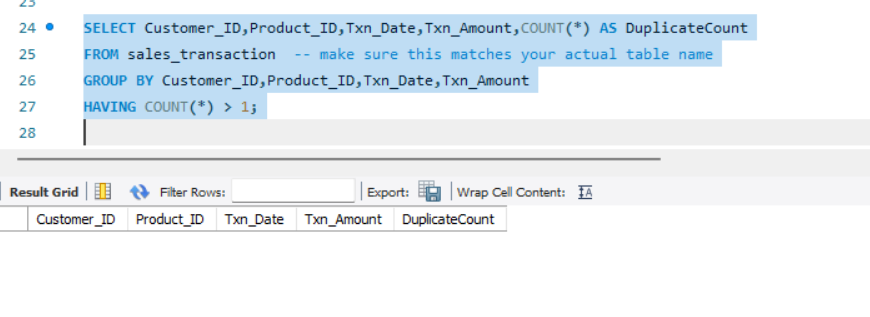



---

Q8 Enforcing Referential Integrity

Assume the following Customers-Master table

A) 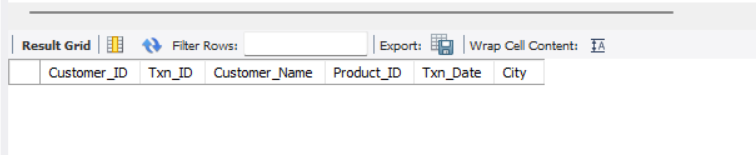


---

